In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.data_loader import load_processed_prices

from src.portfolio import (
    annualized_returns,
    covariance_matrix
)


In [2]:
prices = load_processed_prices()

prices.head()

,BND,SPY,TSLA
Date,,,
2015-01-02,59.205647,169.687851,14.620667
2015-01-05,59.377579,166.623306,14.006000
2015-01-06,59.549515,165.053909,14.085333
2015-01-07,59.585354,167.110672,14.063333
2015-01-08,59.492188,170.076096,14.041333


In [3]:
prices = prices[
    ["TSLA", "SPY", "BND"]
]

prices.head()

,TSLA,SPY,BND
Date,,,
2015-01-02,14.620667,169.687851,59.205647
2015-01-05,14.006000,166.623306,59.377579
2015-01-06,14.085333,165.053909,59.549515
2015-01-07,14.063333,167.110672,59.585354
2015-01-08,14.041333,170.076096,59.492188


Calculate Daily Returns

In [4]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002904
2015-01-06,0.005664,-0.009419,0.002896
2015-01-07,-0.001562,0.012461,0.000602
2015-01-08,-0.001564,0.017745,-0.001564
2015-01-09,-0.018802,-0.008014,0.001686


Historical Annual Returns

In [5]:
historical_returns = annualized_returns(returns)

historical_returns

TSLA    0.454239
SPY     0.144320
BND     0.020250
dtype: float64

In [6]:
tsla = prices["TSLA"]

Calculate Tesla's Forecasted Return

In [7]:
forecast = pd.read_csv(
    "../data/processed/tsla_future_forecast.csv"
)

last_actual_price = prices["TSLA"].iloc[-1]

last_forecast_price = forecast["Forecasted_Price"].iloc[-1]

tsla_expected_return = (
    last_forecast_price - last_actual_price
) / last_actual_price

print(f"Expected Tesla Return: {tsla_expected_return:.2%}")

Expected Tesla Return: -30.49%


Compute Covariance Matrix

In [8]:
cov_matrix = covariance_matrix(returns)

cov_matrix

,TSLA,SPY,BND
TSLA,0.326926,0.049820,0.001790
SPY,0.049820,0.031169,0.001086
BND,0.001790,0.001086,0.002822


Visualize the Covariance Matrix

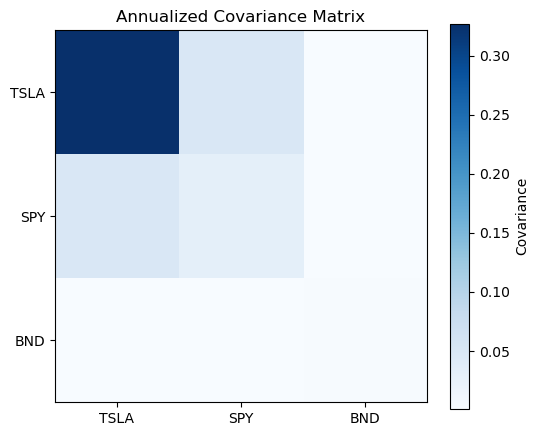

In [9]:
plt.figure(figsize=(6, 5))

plt.imshow(cov_matrix, cmap="Blues")

plt.colorbar(label="Covariance")

plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns)

plt.yticks(range(len(cov_matrix.columns)), cov_matrix.columns)

plt.title("Annualized Covariance Matrix")

plt.show()

In [11]:
from scipy.optimize import minimize

Portfolio Performance Function

In [12]:
def portfolio_performance(weights, returns, cov_matrix):
    """
    Calculate annual portfolio return and volatility.
    """

    portfolio_return = np.sum(weights * returns)

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    return portfolio_return, portfolio_volatility

Negative Sharpe Ratio

In [13]:
def negative_sharpe(weights, returns, cov_matrix, risk_free_rate=0.02):

    portfolio_return, portfolio_volatility = portfolio_performance(
        weights,
        returns,
        cov_matrix
    )

    sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    return -sharpe

Optimization Constraints

In [15]:
historical_returns = annualized_returns(returns)

historical_returns

TSLA    0.454239
SPY     0.144320
BND     0.020250
dtype: float64

In [16]:
expected_returns = historical_returns.copy()

expected_returns["TSLA"] = tsla_expected_return

expected_returns

TSLA   -0.304859
SPY     0.144320
BND     0.020250
dtype: float64

In [17]:
num_assets = len(expected_returns)

constraints = (
    {
        "type": "eq",
        "fun": lambda x: np.sum(x) - 1
    },
)

bounds = tuple((0, 1) for _ in range(num_assets))

initial_weights = np.repeat(
    1 / num_assets,
    num_assets
)

Objective Function

In [18]:
def portfolio_performance(weights, returns, cov_matrix):
    portfolio_return = np.dot(weights, returns)

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    sharpe = portfolio_return / portfolio_volatility

    return portfolio_return, portfolio_volatility, sharpe

Function to Minimize

In [19]:
def negative_sharpe(weights):
    return -portfolio_performance(
        weights,
        expected_returns.values,
        cov_matrix.values
    )[2]

Optimize

In [20]:
from scipy.optimize import minimize

optimal = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

Results

In [21]:
optimal_weights = optimal.x

portfolio_return, portfolio_risk, portfolio_sharpe = portfolio_performance(
    optimal_weights,
    expected_returns.values,
    cov_matrix.values
)

print("Optimal Weights")
print("----------------")
for asset, weight in zip(expected_returns.index, optimal_weights):
    print(f"{asset}: {weight:.2%}")

print("\nExpected Return:", f"{portfolio_return:.2%}")
print("Risk:", f"{portfolio_risk:.2%}")
print("Sharpe Ratio:", round(portfolio_sharpe,2))

Optimal Weights
----------------
TSLA: 0.00%
SPY: 44.82%
BND: 55.18%

Expected Return: 7.59%
Risk: 8.75%
Sharpe Ratio: 0.87


Given the forecast, Tesla should not be included because its expected return is negative.

In [22]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

weights_record = []